In [1]:
import pandas as pd

df = pd.read_csv('archive/merged_output_ready.csv')
print(df)

                timestamp  ADALAR_BOSTANCI  ADALAR_BURGAZADA  ADALAR_BUYUKADA  \
0     2023-01-01 00:00:00         0.000000          0.000000         0.000000   
1     2023-01-01 01:00:00         0.000000          0.000000         0.000000   
2     2023-01-01 02:00:00         0.000000          0.000000         0.000000   
3     2023-01-01 03:00:00         0.000000          0.000000         0.000000   
4     2023-01-01 04:00:00         0.000000          0.000000         0.000000   
...                   ...              ...               ...              ...   
8734  2023-12-31 19:00:00         0.090103          0.032389         0.064713   
8735  2023-12-31 20:00:00         0.036928          0.000000         0.038665   
8736  2023-12-31 21:00:00         0.028065          0.020243         0.031339   
8737  2023-12-31 22:00:00         0.026588          0.000000         0.001221   
8738  2023-12-31 23:00:00         0.000492          0.000000         0.000000   

      ADALAR_HEYBELIADA  AD

In [2]:

print(df.head())

print("\nSütunlar:")
print(df.columns)

print("\nVeri bilgisi:")
print(df.info())

print("\nİstatistikler:")
print(df.describe())

             timestamp  ADALAR_BOSTANCI  ADALAR_BURGAZADA  ADALAR_BUYUKADA  \
0  2023-01-01 00:00:00              0.0               0.0              0.0   
1  2023-01-01 01:00:00              0.0               0.0              0.0   
2  2023-01-01 02:00:00              0.0               0.0              0.0   
3  2023-01-01 03:00:00              0.0               0.0              0.0   
4  2023-01-01 04:00:00              0.0               0.0              0.0   

   ADALAR_HEYBELIADA  ADALAR_KARTAL  ADALAR_KINALIADA  \
0                0.0            0.0               0.0   
1                0.0            0.0               0.0   
2                0.0            0.0               0.0   
3                0.0            0.0               0.0   
4                0.0            0.0               0.0   

   ADALAR-BOSTANCI_BURGAZADA  ADALAR-BOSTANCI_BUYUKADA  \
0                   0.081545                       0.0   
1                   0.115880                       0.0   
2             

In [3]:
# Örnek olarak kritik bir durak seçiyoruz
target_station = "YENIKAPI - HAVALIMANI_YENIKAPI"

# Hedef değişken
y = df[target_station]

# Feature set (şimdilik sadece zaman)
X = df[["hour", "day_of_week", "month"]]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX örnek:")
print(X.head())

print("\ny örnek:")
print(y.head())


X shape: (8739, 3)
y shape: (8739,)

X örnek:
   hour  day_of_week  month
0     0            6      1
1     1            6      1
2     2            6      1
3     3            6      1
4     4            6      1

y örnek:
0    0.171894
1    0.236534
2    0.162742
3    0.108590
4    0.051578
Name: YENIKAPI - HAVALIMANI_YENIKAPI, dtype: float64


In [4]:
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("\nTrain time range:")
print(df["timestamp"].iloc[0], "→", df["timestamp"].iloc[split_index-1])

print("\nTest time range:")
print(df["timestamp"].iloc[split_index], "→", df["timestamp"].iloc[-1])


Train set size: (6991, 3)
Test set size: (1748, 3)

Train time range:
2023-01-01 00:00:00 → 2023-10-19 16:00:00

Test time range:
2023-10-19 17:00:00 → 2023-12-31 23:00:00


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1️Modeli tanımla
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 2️ Modeli eğit
rf_model.fit(X_train, y_train)

# 3️ Test seti tahminleri
y_pred = rf_model.predict(X_test)

# 4️ Performans metrikleri
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)


Random Forest MAE: 0.02199825054379779
Random Forest RMSE: 0.045054580032721614


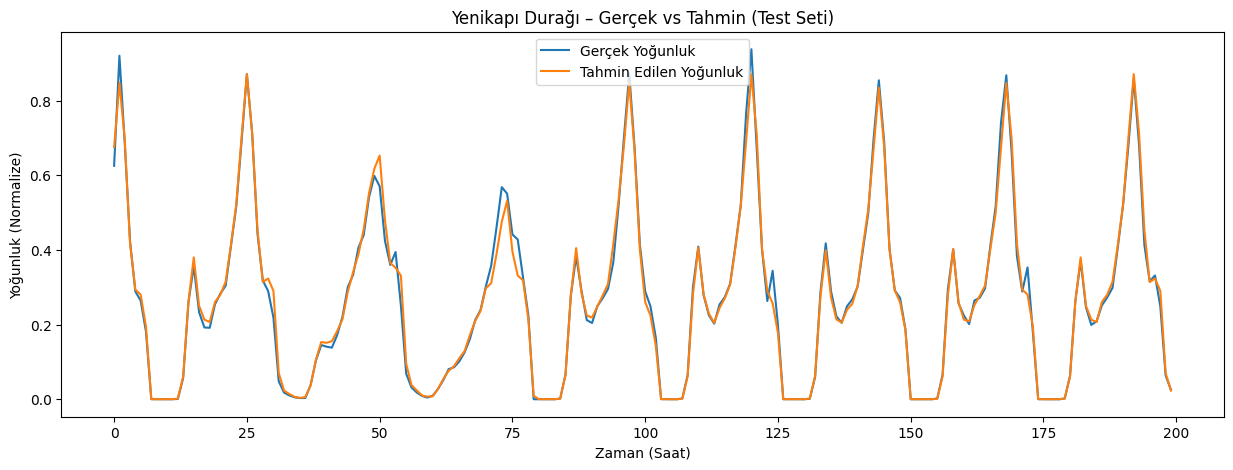

In [6]:
import matplotlib.pyplot as plt

# İlk 200 saatlik test verisini çizelim 
n = 200

plt.figure(figsize=(15,5))
plt.plot(y_test.values[:n], label="Gerçek Yoğunluk")
plt.plot(y_pred[:n], label="Tahmin Edilen Yoğunluk")

plt.title("Yenikapı Durağı – Gerçek vs Tahmin (Test Seti)")
plt.xlabel("Zaman (Saat)")
plt.ylabel("Yoğunluk (Normalize)")
plt.legend()
plt.show()


       Feature  Importance
0         hour    0.908134
1  day_of_week    0.057066
2        month    0.034800


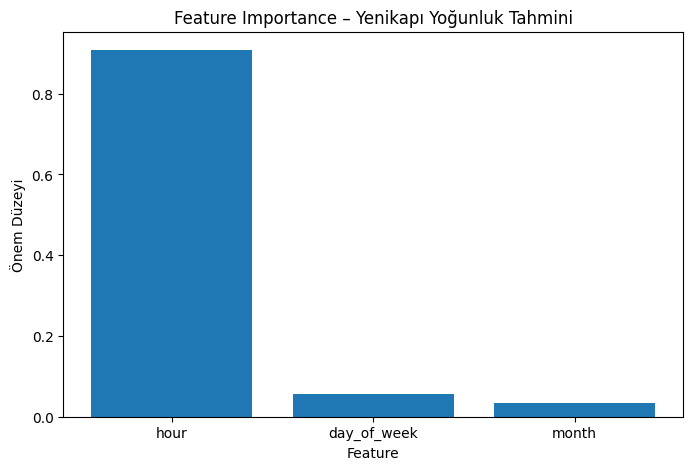

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance'ları al
importances = rf_model.feature_importances_
features = X.columns

# DataFrame'e çevir
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance – Yenikapı Yoğunluk Tahmini")
plt.ylabel("Önem Düzeyi")
plt.xlabel("Feature")
plt.show()


In [8]:
#“Modelimiz, yoğunluğun %90’ından fazlasının gün içindeki saatsel döngüden kaynaklandığını ortaya koymaktadır.”

In [9]:
import xgboost
print(xgboost.__version__)


3.0.2


In [10]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Mutlu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1️ Model tanımı
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# 2️ Model eğitimi
xgb_model.fit(X_train, y_train)

# 3️ Tahmin
y_pred_xgb = xgb_model.predict(X_test)

# 4️ Metrikler
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost MAE: 0.0243106685057852
XGBoost RMSE: 0.04282133552885074


In [13]:
print(df['timestamp'].dtype)


object


In [17]:
print(df['timestamp'].head())
print(df['timestamp'].dtype)
print(type(df['timestamp'].iloc[0]))


0    2023-01-01 00:00:00
1    2023-01-01 01:00:00
2    2023-01-01 02:00:00
3    2023-01-01 03:00:00
4    2023-01-01 04:00:00
Name: timestamp, dtype: object
object
<class 'str'>


In [18]:
import pandas as pd

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format='%Y-%m-%d %H:%M:%S',  
    errors='raise'               
)


In [19]:
print(df['timestamp'].dtype)
print(type(df['timestamp'].iloc[0]))


datetime64[ns]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [20]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month


In [21]:
df[['timestamp', 'hour', 'day_of_week', 'month']].head()


,timestamp,hour,day_of_week,month
0,2023-01-01 00:00:00,0,6,1
1,2023-01-01 01:00:00,1,6,1
2,2023-01-01 02:00:00,2,6,1
3,2023-01-01 03:00:00,3,6,1
4,2023-01-01 04:00:00,4,6,1


In [22]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month


In [26]:
print(df.columns)



Index(['timestamp', 'ADALAR_BOSTANCI', 'ADALAR_BURGAZADA', 'ADALAR_BUYUKADA',
       'ADALAR_HEYBELIADA', 'ADALAR_KARTAL', 'ADALAR_KINALIADA',
       'ADALAR-BOSTANCI_BURGAZADA', 'ADALAR-BOSTANCI_BUYUKADA',
       'ADALAR-BOSTANCI_HEYBELIADA',
       ...
       'YENIKAPI - HAVALIMANI_UCYUZLU', 'YENIKAPI - HAVALIMANI_ULUBATLI',
       'YENIKAPI - HAVALIMANI_YENIBOSNA', 'YENIKAPI - HAVALIMANI_YENIKAPI',
       'YENIKAPI - HAVALIMANI_ZEYTINBURNU', 'YENIKAPI-ADALAR_YENI KABATAS',
       'YENIKOY-BEYKOZ_YENIKOY', 'day_of_week', 'month', 'hour'],
      dtype='object', length=484)


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Zaman özellikleri
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# station_id one-hot encoding
df_encoded = pd.get_dummies(df, columns=['station_id'])

# Feature ve target
X = df_encoded.drop(columns=['density', 'timestamp'])
y = df_encoded['density']

# Zaman bazlı split (shuffle YOK)
split_time = '2023-10-19 17:00:00'

X_train = X[df['timestamp'] < split_time]
X_test  = X[df['timestamp'] >= split_time]

y_train = y[df['timestamp'] < split_time]
y_test  = y[df['timestamp'] >= split_time]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


KeyError: "None of [Index(['station_id'], dtype='object')] are in the [columns]"